In [1]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
import sys
from pathlib import Path
%matplotlib widget
from scipy.stats import t, truncnorm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import joblib
import pandas as pd
from importlib import reload
import json

In [2]:
import libs.custom_prospector_tools as cpt
cpt = reload(cpt)

In [3]:
filter_list = '/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/FILTER/SPHEREx_306/fiducial_filters.txt'
filters, lamb_obs = cpt.read_filters(filter_list, return_lamb_obs=True)

In [4]:
pros_obj = cpt.custom_prospector(sfh_type='continuity_sfh', filters=filters)

In [5]:
myparams = pros_obj.create_myparams()   # create a template parameter dictionary for us to use 
myparams

{'zred': 0.1,
 'logmass': 10,
 'logzsol': 0.0,
 'nbins': 7,
 'logsfr_ratios': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'dust2': 0.0,
 'dust_ratio': 0.0,
 'dust_index': -1.0,
 'duste_gamma': 0.01,
 'duste_umin': 0.01,
 'duste_qpah': 0.0,
 'add_neb_emission': False,
 'add_neb_continuum': True,
 'gas_logz': 0.0,
 'gas_logu': -2.0,
 'add_agn': False,
 'fagn': 0.0001,
 'agn_tau': 5.0}

In [6]:
myparams = {'zred': 0.01,
 'logmass': 10,
 'logzsol': 0.0,
 'nbins': 5,
 'logsfr_ratios': [0.0, 0.0, 0.0, 0.0],
 'dust2': 1.0,
 'dust_ratio': 1.0,
 'dust_index': -1.2,
 'duste_gamma': 0.01,
 'duste_umin': 1.0,
 'duste_qpah': 2.0,
 'add_neb_emission': False,
 'add_neb_continuum': False,
 'gas_logz': 0.0,
 'gas_logu': -2.0,
 'add_agn': False,
 'fagn': 0.0001,
 'agn_tau': 5.0}

In [7]:
lbs, flux, flux_conv, mfrac = pros_obj.generate_spectra(myparams=myparams, wl_min=0.2, wl_max=5.5)

# Define default parameters and parameters to train

This section defines the starting point of an emulator so make sure they are properly stored

In [10]:
# by hand explicitly create an example of training parameters
train_param_example = {'zred': 0.01,
 'logmass': 10,
 'logzsol': 0.0,
 'logsfr_ratios': [0.0, 0.0, 0.0, 0.0],
 'dust2': 1.0,
 'dust_index': -1.2,
 'duste_qpah': 2.0,
 }

default_params = {k: v for k, v in myparams.items() if k not in train_param_example}
# train_params = {k: v for k, v in myparams.items() if k not in default_params}
train_param_keys = []
for _, key in enumerate(train_param_example.keys()):
    if key != 'logsfr_ratios':
        train_param_keys.append(key)
    else:
        for i in range(default_params['nbins']-1):
            train_param_keys.append(f"logsfr_ratios{i}")

# Creating Training Data

In [ ]:
nsample_train = int(1e5)
n_features = len(train_param_keys)

rng = np.random.default_rng(seed=123)
# rng = np.random.default_rng(seed=1234)

rv = t(df=2, loc=0.0, scale=3.0)
lostsfr_ratios_train = np.array([rv.ppf(rng.uniform(rv.cdf(-5), rv.cdf(5), nsample_train)) for i in range(default_params['nbins']-1)]).T

# zu_train = rng.uniform(
#     np.log1p(0.05),
#     np.log1p(3.0),
#     size=nsample_train
# )
zu_train = rng.uniform(
    np.log1p(0.0),
    np.log1p(3.0),
    size=nsample_train
)

z_samples_train = np.expm1(zu_train)

# u = rng.random(nsample_train)
# a = 1.0
# z_samples_train = -np.log(1 - u * (1 - np.exp(-3*a))) / a

params_train = {
    'zred': z_samples_train,
    'logmass': rng.uniform(7.5, 13.5, nsample_train),
    'logzsol': rng.uniform(-2, 0.2, nsample_train),
    'logsfr_ratios': list(lostsfr_ratios_train),
    'dust2': truncnorm.rvs((0-0.3)/3, (4-0.3)/3, loc=0.3, scale=3, size=nsample_train, random_state=rng),
    'dust_index': rng.uniform(-1.2, 0.4, nsample_train),
    'duste_qpah': truncnorm.rvs((0-2)/4, (7-2)/4, loc=2.0, scale=4.0, size=nsample_train, random_state=rng),
}
df_train_params = pd.DataFrame(params_train)
x_train = cpt.emu_params_to_x(emu_params=params_train)


In [ ]:

read_flux = False

if not read_flux:
    mfrac_train = np.zeros(nsample_train)
    flux_train = np.zeros((nsample_train, len(lbs)))
    # logflux_train = np.zeros((nsample_train, len(lbs)))

    for i in range(nsample_train):
        print(f'\rCreating spectra {i+1}/{nsample_train}', end="")
        train_param_i = cpt.emu_param_to_pros_param(df_train_params.iloc[i])

        lbs, flux, flux_conv, mfrac = pros_obj.generate_spectra(myparams=train_param_i, wl_min=0.2, wl_max=5.5)
        h = flux<0
        flux_interp = np.interp(lbs[h], lbs[~h], flux[~h])
        flux[h] = flux_interp
        mfrac_train[i] = mfrac
        flux_train[i] = flux
        # logflux_train[i] = np.log10(flux)
    np.savez_compressed(f'random_samples/train/train_spectra_{int(nsample_train/1000)}k.npz', 
                        lbs=lbs, 
                        flux=flux_train, 
                        # logflux=logflux_train, 
                        mfrac=mfrac_train,
                        train_param_keys=np.asarray(train_param_keys), 
                        default_params=json.dumps(default_params))

else:
    with np.load(f'random_samples/train/train_spectra_{int(nsample_train/1000)}k.npz') as saved_fluxes:

        mfracs = saved_fluxes['mfrac']
        flux_train = saved_fluxes['flux']
        # logflux_train = saved_fluxes['logflux']
        # train_param_keys=saved_fluxes['train_param_keys'].tolist()
        # default_params = json.loads(saved_fluxes["default_params"].item())

Creating spectra 100000/100000

In [ ]:
# df_params_train.to_parquet(f'random_samples/train/train_params_{int(nsample_train/1000)}k.parq', index=False)

# PCA

In [ ]:
logflux_train = np.log10(flux_train)

In [ ]:
nc = 20
pca = PCA(n_components=nc)
# pca.fit(log_fluxes)
pca_coef = pca.fit_transform(logflux_train)
# flux_transform = pca.inverse_transform(pca_coef)

pca_modes = pca.components_
# rseds = pca.inverse_transform(rcoefs)
pca_mean = pca.mean_
print(pca.explained_variance_ratio_)

[9.75107446e-01 2.20584251e-02 2.07835258e-03 5.56911654e-04
 9.72766054e-05 3.82764472e-05 2.38837948e-05 1.23577266e-05
 5.99550305e-06 4.62010088e-06 2.91554454e-06 1.76702971e-06
 1.23471988e-06 1.12020223e-06 9.14468194e-07 7.49332980e-07
 7.05995937e-07 6.66366894e-07 5.77867553e-07 4.87861094e-07]


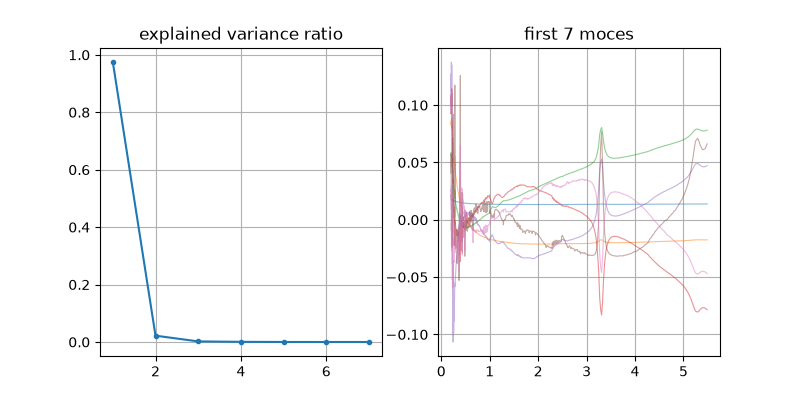

In [ ]:
n_pca_show = 7

plt.close()
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].plot(np.arange(1, n_pca_show+1), pca.explained_variance_ratio_[:n_pca_show], '.-')
# ax.set_yscale('log')
ax[0].grid()
ax[0].set_title("explained variance ratio")
ax[1].plot(lbs, pca_modes[:n_pca_show].T, linewidth=0.8, alpha=0.5)
ax[1].set_title(f"first {n_pca_show} moces")
ax[1].grid()

Text(0.5, 1.0, 'z=2.9044, rel L2 err=0.0037')

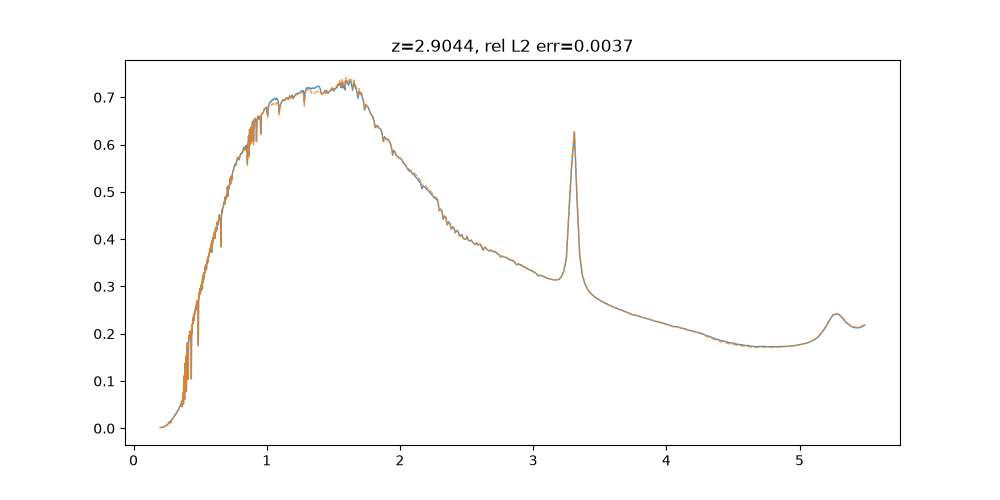

In [ ]:
idx = 13

nmodes = 20
pca_logflux = pca_coef[idx][:nmodes] @ pca_modes[:nmodes] + pca_mean
rel_l2_err_pca = np.linalg.norm(10**(logflux_train[idx])-10**pca_logflux)/np.linalg.norm(10**(logflux_train[idx]))

plt.close()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lbs, 10**logflux_train[idx], linewidth=1, alpha=0.8)
ax.plot(lbs, 10**pca_logflux, '--', linewidth=1, alpha=0.8)
# ax.plot(lbs, rseds_transform[idx], ':', linewidth=1, alpha=0.8)
ax.set_title(f'z={params_train['zred'][idx]:.4f}, rel L2 err={rel_l2_err_pca:.4f}')

In [ ]:
np.savez_compressed(f'random_samples/pca/logflux_pca_modes_{int(nsample_train/1000)}k.npz', 
                    lbs=lbs, modes=pca_modes, mean=pca_mean,
                    train_param_keys=np.asarray(train_param_keys), 
                    default_params=json.dumps(default_params))

In [ ]:
x_scaler = StandardScaler()
x_train_scaled = x_scaler.fit_transform(x_train)
coef_train = pca_coef[:, :nmodes]
coef_train_scaled = coef_train

In [ ]:
np.savez(f'random_samples/train/train_x_coef_mfrac_{int(nsample_train/1000)}k.npz', x=x_train, coef=coef_train, mfrac=mfrac_train, 
         train_param_keys=np.asarray(train_param_keys), default_params=json.dumps(default_params))

# Validation set

In [ ]:
rng_val = np.random.default_rng(seed=456)
nsample_val = 10000

re_genereate_val_param = True
if re_genereate_val_param:
    rv = t(df=2, loc=0.0, scale=3.0)
    lostsfr_ratios_val = np.array([rv.ppf(rng_val.uniform(rv.cdf(-5), rv.cdf(5), nsample_val)) for i in range(default_params['nbins']-1)]).T

    # zu_val = rng_val.uniform(
    #     np.log1p(0.05),
    #     np.log1p(3.0),
    #     size=nsample_val
    # )
    zu_val = rng_val.uniform(
        np.log1p(0.0),
        np.log1p(3.0),
        size=nsample_val
    )
    zval_samples = np.expm1(zu_val)

    # u = rng_val.random(nsample_val)
    # a = 1.0
    # zval_samples = -np.log(1 - u * (1 - np.exp(-3*a))) / a

    val_params = {
        'zred': zval_samples,
        'logmass': rng_val.uniform(7.5, 13.5, nsample_val),
        'logzsol': rng_val.uniform(-2, 0.2, nsample_val),
        'logsfr_ratios': list(lostsfr_ratios_val),
        'dust2': truncnorm.rvs((0-0.3)/3, (4-0.3)/3, loc=0.3, scale=3, size=nsample_val, random_state=rng_val),
        'dust_index': rng_val.uniform(-1.2, 0.4, nsample_val),
        'duste_qpah': truncnorm.rvs((0-2)/4, (7-2)/4, loc=2.0, scale=4.0, size=nsample_val, random_state=rng_val),
    }
    df_val_params = pd.DataFrame(val_params)

    x_val = cpt.emu_params_to_x(emu_params=val_params)
    df_val_params.to_parquet(f'random_samples/validation/validation_params_{int(nsample_val/1000)}k.parq', index=False)

else:
    df_val_params = pd.read_parquet(f'random_samples/validation/validation_params_{int(nsample_val/1000)}k.parq')
    # df_val_params = pd.read_parquet(f'random_samples/validation/validation_params_lowz_{int(nsample_val/1000)}k.parq')
    x_val = cpt.emu_params_to_x(df=df_val_params)

In [ ]:
read_val = False

if not read_val:
    flux_val = np.zeros((nsample_val, len(lbs)))
    coef_val = np.zeros((nsample_val, nmodes))
    mfrac_val = np.zeros(nsample_val)

    for i in range(nsample_val):
        print(f'\revaluate {i+1}/{nsample_val}...', end="")
        val_param_i = cpt.emu_param_to_pros_param(df_val_params.iloc[i])
        lbs, flux_pros, flux_conv, mfrac = pros_obj.generate_spectra(myparams=val_param_i, wl_min=0.2, wl_max=5.5)
        h = flux_pros < 0
        flux_pros_interp = np.interp(lbs[h], lbs[~h], flux_pros[~h])
        flux_pros[h] = flux_pros_interp
        flux_val[i] = flux_pros
        logflux_pros = np.log10(flux_pros)
        c_val_i = (logflux_pros-pca_mean) @ pca_modes[:nmodes].T
        coef_val[i] = c_val_i
        mfrac_val[i] = mfrac

    np.savez_compressed(f'random_samples/validation/validation_x_coef_mfrac_flux_{int(nsample_val/1000)}k.npz', 
                        lbs=lbs, x=x_val, flux=flux_val, coef=coef_val, mfrac=mfrac_val,
                        train_param_keys=np.asarray(train_param_keys), default_params=json.dumps(default_params))

else:
    dat = np.load(f'random_samples/validation/validation_x_coef_mfrac_flux_{int(nsample_val/1000)}k.npz')

    flux_val = dat['flux']
    x_val = dat['x']
    coef_val = dat['coef']
    mfrac_val = dat['mfrac']

coef_val_scaled = coef_val

evaluate 10000/10000...

# Test set

In [ ]:
rng_test = np.random.default_rng(seed=789)
nsample_test = 10000

re_genereate_test_param = True
if re_genereate_test_param:
    rv = t(df=2, loc=0.0, scale=3.0)
    lostsfr_ratios_test = np.array([rv.ppf(rng_test.uniform(rv.cdf(-5), rv.cdf(5), nsample_test)) for i in range(default_params['nbins']-1)]).T

    # zu_test = rng_test.uniform(
    #     np.log1p(0.05),
    #     np.log1p(3.0),
    #     size=nsample_test
    # )
    zu_test = rng_test.uniform(
        np.log1p(0.0),
        np.log1p(3.0),
        size=nsample_test
    )
    ztest_samples = np.expm1(zu_test)

    # u = rng_test.random(nsample_test)
    # a = 1.0
    # ztest_samples = -np.log(1 - u * (1 - np.exp(-3*a))) / a

    test_params = {
        'zred': ztest_samples,
        'logmass': rng_test.uniform(7.5, 13.5, nsample_test),
        'logzsol': rng_test.uniform(-2, 0.2, nsample_test),
        'logsfr_ratios': list(lostsfr_ratios_test),
        'dust2': truncnorm.rvs((0-0.3)/3, (4-0.3)/3, loc=0.3, scale=3, size=nsample_test, random_state=rng_test),
        'dust_index': rng_test.uniform(-1.2, 0.4, nsample_test),
        'duste_qpah': truncnorm.rvs((0-2)/4, (7-2)/4, loc=2.0, scale=4.0, size=nsample_test, random_state=rng_test),
    }
    df_test_params = pd.DataFrame(test_params)

    x_test = cpt.emu_params_to_x(emu_params=test_params)
    df_test_params.to_parquet(f'random_samples/test/test_params_{int(nsample_test/1000)}k.parq', index=False)

else:
    df_test_params = pd.read_parquet(f'random_samples/test/test_params_{int(nsample_test/1000)}k.parq')
    # df_test_params = pd.read_parquet(f'random_samples/test/test_params_lowz_{int(nsample_test/1000)}k.parq')
    x_test = cpt.emu_params_to_x(df=df_test_params)

In [ ]:
read_test = False

if not read_test:
    flux_test = np.zeros((nsample_test, len(lbs)))
    coef_test = np.zeros((nsample_test, nmodes))
    mfrac_test = np.zeros(nsample_test)

    for i in range(nsample_test):
        print(f'\revaluate {i+1}/{nsample_test}...', end="")
        test_param_i = cpt.emu_param_to_pros_param(df_test_params.iloc[i])
        lbs, flux_pros, flux_conv, mfrac = pros_obj.generate_spectra(myparams=test_param_i, wl_min=0.2, wl_max=5.5)
        h = flux_pros < 0
        flux_pros_interp = np.interp(lbs[h], lbs[~h], flux_pros[~h])
        flux_pros[h] = flux_pros_interp
        flux_test[i] = flux_pros
        logflux_pros = np.log10(flux_pros)
        c_test_i = (logflux_pros-pca_mean) @ pca_modes[:nmodes].T
        coef_test[i] = c_test_i
        mfrac_test[i] = mfrac

    np.savez_compressed(f'random_samples/test/test_x_coef_mfrac_flux_{int(nsample_test/1000)}k.npz', 
                        lbs=lbs, x=x_test, flux=flux_test, coef=coef_test, mfrac=mfrac_test,
                        train_param_keys=np.asarray(train_param_keys), default_params=json.dumps(default_params))

else:
    dat = np.load(f'random_samples/test/test_x_coef_mfrac_flux_{int(nsample_test/1000)}k.npz')

    flux_test = dat['flux']
    x_test = dat['x']
    coef_test = dat['coef']
    mfrac_test = dat['mfrac']

coef_test_scaled = coef_test

evaluate 10000/10000...